In [2]:
#Importing and Evironmenatal SetUp
import time
import requests
import zipfile
import io
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

In [3]:
#Extracting the Data from the page webiste
def loading_data():
  page_url_link =  "https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones"
  response=requests.get (page_url_link  )
  if response.status_code ==  200:    #Request was Successful
    soup = BeautifulSoup    ( response.content,'html.parser'  )
    link = soup.select_one  ( 'a[href$=".zip"]' )['href']
    download_link = 'https://archive.ics.uci.edu'+link
    response_url = requests.get(  download_link )

    if response_url.status_code == 200:
      with zipfile.ZipFile(io.BytesIO(response_url.content)) as outer_zip_file:
        outer_zip_file.printdir()
        print('\n')
        with outer_zip_file.open('UCI HAR Dataset.zip') as inner_zip_file:
          with zipfile.ZipFile(io.BytesIO(inner_zip_file.read())) as inner_zip:
            inner_zip.printdir()
            with inner_zip.open('UCI HAR Dataset/features.txt') as f_file:
              features_df = pd.read_csv(f_file, sep=r'\s+', header=None)
              features_Name = features_df[1].tolist()
            with inner_zip.open('UCI HAR Dataset/train/X_train.txt') as myfile_x:
              df  =  pd.read_csv( myfile_x , sep = r'\s+' , header  =  None)
              df.columns = features_Name
            with inner_zip.open('UCI HAR Dataset/train/y_train.txt') as myfile_y:
              y = pd.read_csv(  myfile_y , sep = r'\s+' , header = None )
              return df, y

    else :
      raise Exception( "Failed To Download the Zip file ")
  else :
   raise Exception( "Failed to Reach UCI Repository ")


In [4]:
X_train , y_train = loading_data()

File Name                                             Modified             Size
UCI HAR Dataset.names                          2023-05-22 15:22:54         6304
UCI HAR Dataset.zip                            2023-05-22 15:22:54     60999314


File Name                                             Modified             Size
UCI HAR Dataset/                               2015-02-15 19:13:56            0
UCI HAR Dataset/.DS_Store                      2015-02-15 19:13:56         6148
__MACOSX/                                      2015-02-15 19:14:12            0
__MACOSX/UCI HAR Dataset/                      2015-02-15 19:14:12            0
__MACOSX/UCI HAR Dataset/._.DS_Store           2015-02-15 19:13:56          120
UCI HAR Dataset/activity_labels.txt            2012-10-10 16:55:30           80
__MACOSX/UCI HAR Dataset/._activity_labels.txt 2012-10-10 16:55:30          226
UCI HAR Dataset/features.txt                   2012-10-11 14:41:06        15785
__MACOSX/UCI HAR Dataset/._features.tx

In [5]:
print ( 'X_Train_Shape: ', X_train.shape)
print ( 'y_Train_Shape: ', y_train.shape)

X_Train_Shape:  (7352, 561)
y_Train_Shape:  (7352, 1)


In [6]:
y_train_encoded = LabelEncoder().fit_transform(y_train.values.ravel())
X_train_scaled   = StandardScaler().fit_transform(X_train)

In [7]:
#train_test_split
X_train_full , X_test_full , y_train_full , y_test_full = train_test_split(X_train_scaled , y_train_encoded , test_size = 0.2 , random_state = 42)

In [8]:
X_train.head()
# y_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [9]:
#BaseLine Classifier 1 ( Logistic Regression )

start_time  = time.time()
lr_base = LogisticRegression(max_iter = 1000  , random_state = 42 )
lr_base.fit(X_train_full  ,  y_train_full )
y_pred_lr_base = lr_base.predict (X_test_full)
end_time  = time.time()
time_lr =  end_time - start_time
acc_lr_base= accuracy_score( y_test_full , y_pred_lr_base )
print("Baseline Model : Logistic Regression (All Features):")
print("Accuracy:", acc_lr_base)
print("Execution Time:", time_lr)
print( '\n')
# print("Running the 10 folds Cross Validation")
# lr_cv_score = cross_val_score ( lr_base , X_train_full , y_train_full, cv=10 , n_jobs=-1)
# print(f"CV Mean Accuracy:{lr_cv_score.mean():.4f}")

Baseline Model : Logistic Regression (All Features):
Accuracy: 0.9836845683208701
Execution Time: 5.467890977859497




In [10]:
#BaseLine Classifier 2 ( RandomForest Classifier)

start_time   = time.time()
rf_base   = RandomForestClassifier(random_state = 42)
rf_base.fit(X_train_full , y_train_full)
y_pref_rf_base = rf_base.predict( X_test_full)
end_time = time.time()
time_rf  = end_time- start_time
acc_rf_base = accuracy_score( y_test_full , y_pref_rf_base)
print("Baseline Model : RandomForest (All Features):")
print("Accuracy:", acc_rf_base)
print("Execution Time:", time_rf)
print( '\n')
# print("Running the 10 folds Cross Validation")
# rf_cv_score = cross_val_score ( rf_base , X_train_full , y_train_full, cv=10 , n_jobs=-1)
# print(f"CV Mean Accuracy:{rf_cv_score.mean():.4f}")

Baseline Model : RandomForest (All Features):
Accuracy: 0.9775662814411965
Execution Time: 16.913421154022217




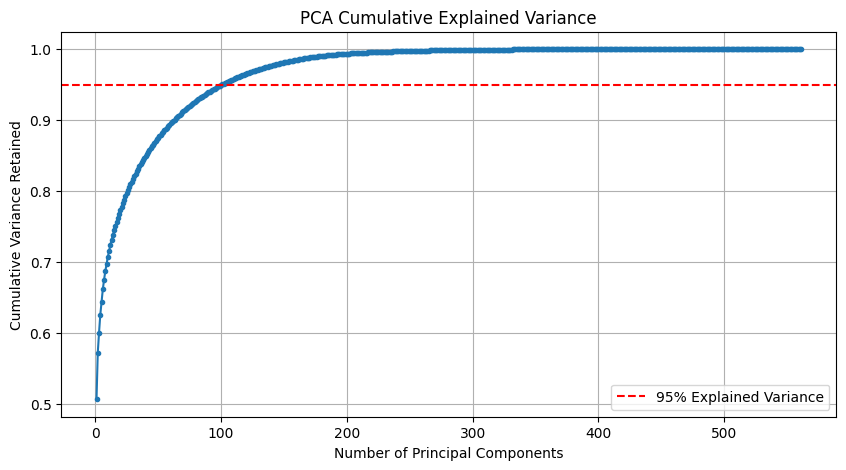

In [11]:
# Before Starting PCA i need to choose The prinncipal Components
import matplotlib.pyplot as plt
pca_test = PCA (n_components=561,  random_state = 42)
pca_test.fit( X_train_full)
cumulative_variance = np.cumsum (  pca_test.explained_variance_ratio_)
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='.', linestyle='-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Retained")
plt.grid(True)
plt.legend()
plt.show()



In [13]:
pca_dynamic = PCA( n_components=0.95 ,random_state=42)
pca_dynamic.fit(X_train_full)
optimal_comp = pca_dynamic.n_components_
print(f"TO KEEP 95% OF THE INFORMATION , PCA SHOUD USE { optimal_comp } COMPONENTS")


TO KEEP 95% OF THE INFORMATION , PCA SHOUD USE 101 COMPONENTS


In [14]:
#PCA REDUCTION TO 101 Components
pca = PCA(n_components=101, random_state = 42)
X_train_pca = pca.fit_transform (X_train_full)
X_test_pca  = pca.transform (X_test_full)

In [15]:
X_train_pca.shape

(5881, 101)

In [16]:
# Logistic Regression With PCA
start_time = time.time()
lr_pca = LogisticRegression(max_iter=1000, random_state= 42,solver='liblinear')
lr_pca.fit(X_train_pca, y_train_full)
y_pred_lr_pca = lr_pca.predict(X_test_pca)
end_time = time.time()
time_pca = end_time - start_time
acc_lr_pca = accuracy_score ( y_test_full, y_pred_lr_pca)
print("\nModel with Reduced Features (Logistic Regression ):")
print("Accuracy:", acc_lr_pca)
print("Execution Time:", time_pca)
print( '\n')
# print("Running the 10 folds Cross Validation")
# lr_pca_cv_score = cross_val_score ( lr_pca , X_train_pca, y_train_full, cv=10 , n_jobs=-1)
# print(f"CV Mean Accuracy:{lr_pca_cv_score.mean():.4f}")


Model with Reduced Features (Logistic Regression ):
Accuracy: 0.9605710401087696
Execution Time: 3.396307945251465




In [17]:
# RandomForest Classifier With PCA
start_time = time.time()
rf_pca = RandomForestClassifier(n_estimators= 50 , n_jobs = -1 ,random_state= 42)
rf_pca.fit(X_train_pca, y_train_full)
y_pred_rf_pca = rf_pca.predict(X_test_pca)
end_time = time.time()
time_pca_rf = end_time - start_time
acc_rf_pca = accuracy_score ( y_test_full, y_pred_rf_pca)
print("\nModel with Reduced Features (RandomForest CLassifier):")
print("Accuracy:", acc_rf_pca)
print("Execution Time:", time_pca_rf)
print( '\n')
# print("Running the 10 folds Cross Validation")
# rf_pca_cv_score = cross_val_score ( rf_pca , X_train_pca, y_train_full, cv=10 , n_jobs=-1)
# print(f"CV Mean Accuracy:{rf_pca_cv_score.mean():.4f}")


Model with Reduced Features (RandomForest CLassifier):
Accuracy: 0.929299796057104
Execution Time: 7.738435506820679




Tested k=10  | Accuracy: 0.8158
Tested k=20  | Accuracy: 0.6621
Tested k=30  | Accuracy: 0.8668
Tested k=40  | Accuracy: 0.9300
Tested k=50  | Accuracy: 0.9443
Tested k=60  | Accuracy: 0.9361
Tested k=70  | Accuracy: 0.9001
Tested k=80  | Accuracy: 0.9069
Tested k=90  | Accuracy: 0.9327
Tested k=100 | Accuracy: 0.9613
Tested k=110 | Accuracy: 0.9436
Tested k=120 | Accuracy: 0.9449
Tested k=130 | Accuracy: 0.9436
Tested k=140 | Accuracy: 0.9551
Tested k=150 | Accuracy: 0.9714


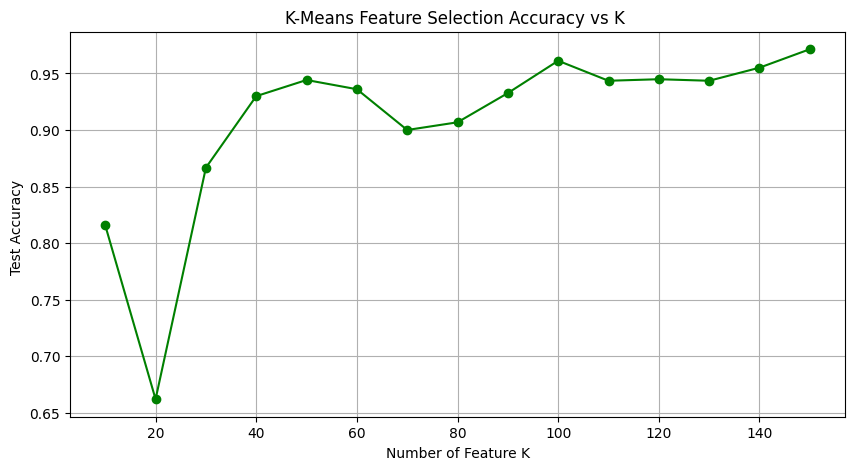

In [18]:
accuracies = []
k_values = range(10, 151, 10)

for K in k_values:
    kmeans = KMeans(n_clusters=K,random_state=42,n_init=10)
    kmeans.fit(X_train_full.T)

    np.random.seed(42)
    selected_indices = []
    for i in range(K):
        indices = np.where(kmeans.labels_ == i)[0]
        selected_indices.append(
        np.random.choice(indices)
        )
    X_train_km = X_train_full[:, selected_indices]
    X_test_km = X_test_full[:, selected_indices]
    lr_test = LogisticRegression(max_iter=1000,random_state=42,solver='liblinear')
    lr_test.fit(X_train_km, y_train_full)
    acc = accuracy_score(y_test_full,lr_test.predict(X_test_km))
    accuracies.append(acc)
    print(f"Tested k={K:<3} | Accuracy: {acc:.4f}")
plt.figure(figsize=(10,5))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='g')
plt.title("K-Means Feature Selection Accuracy vs K ")
plt.xlabel("Number of Feature K")
plt.ylabel("Test Accuracy ")
plt.grid("True")
plt.show()

In [21]:
#K=100 is the best choice with accuracy of 0.9613 and as adding more feature will make model heavy and  slower


kmeans = KMeans(n_clusters=100, random_state=42, n_init=10)
kmeans.fit(X_train_full.T)

np.random.seed(42)
selected_indices = []
for i in range(100):
    indices = np.where(kmeans.labels_ == i)[0]
    selected_indices.append(np.random.choice(indices))

X_train_km = X_train_full[:, selected_indices]
X_test_km = X_test_full[:, selected_indices]

# Logistic Regression With K-Means
start_time = time.time()
lr_km = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
lr_km.fit(X_train_km, y_train_full)
y_pred_lr_km = lr_km.predict(X_test_km)
end_time = time.time()
time_km_lr = end_time - start_time
acc_lr_km = accuracy_score(y_test_full, y_pred_lr_km)

print("\nModel with Reduced Features (Logistic Regression + K-Means):")
print("Accuracy:", acc_lr_km)
print("Execution Time:", time_km_lr)
print('\n')
# print("Running the 10 folds Cross Validation")
# lr_km_cv_score = cross_val_score ( lr_km , X_train_km, y_train_full, cv=10 , n_jobs=-1)
# print(f"CV Mean Accuracy:{lr_km_cv_score.mean():.4f}")


# RandomForest Classifier With K-Means
start_time = time.time()
rf_km = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)
rf_km.fit(X_train_km, y_train_full)
y_pred_rf_km = rf_km.predict(X_test_km)
end_time = time.time()
time_km_rf = end_time - start_time
acc_rf_km = accuracy_score(y_test_full, y_pred_rf_km)

print("\nModel with Reduced Features (RandomForest Classifier + K-Means):")
print("Accuracy:", acc_rf_km)
print("Execution Time:", time_km_rf)
# print("Running the 10 folds Cross Validation")
# rf_km_cv_score = cross_val_score ( rf_km , X_train_km, y_train_full, cv=10 , n_jobs=-1)
# print(f"CV Mean Accuracy:{rf_km_cv_score.mean():.4f}")


Model with Reduced Features (Logistic Regression + K-Means):
Accuracy: 0.9612508497620667
Execution Time: 1.406956434249878



Model with Reduced Features (RandomForest Classifier + K-Means):
Accuracy: 0.9721278042148198
Execution Time: 2.5727932453155518


In [31]:
import joblib

print(f"{'FINAL HAR MODEL BENCHMARK COMPARISON':^75}")
print(f"{'Model Type':<40} | {'Accuracy (%)':<14} | {'Time (s)'}")
print("-"*75)
print(f"{'Logistic Regression (Baseline)':<40} | {acc_lr_base * 100:>10.2f}%    | {time_lr:.3f}")
print(f"{'Random Forest (Baseline)':<40} | {acc_rf_base * 100:>10.2f}%    | {time_rf:.3f}")
print(f"{'Logistic Regression (PCA - 101)':<40} | {acc_lr_pca * 100:>10.2f}%    | {time_pca:.3f}")
print(f"{'Random Forest (PCA - 101)':<40} | {acc_rf_pca * 100:>10.2f}%    | {time_pca_rf:.3f}")
print(f"{'Logistic Regression (K-Means - 100)':<40} | {acc_lr_km * 100:>10.2f}%    | {time_km_lr:.3f}")
print(f"{'Random Forest (K-Means - 100)':<40} | {acc_rf_km * 100:>10.2f}%    | {time_km_rf:.3f}")



rf_time_reduction = ((time_rf - time_km_rf) / time_rf) * 100
rf_acc_drop = (acc_rf_base * 100) - (acc_rf_km * 100)

lr_time_reduction = ((time_lr - time_km_lr) / time_lr) * 100
lr_acc_drop = (acc_lr_base * 100) - (acc_lr_km * 100)

print("\nPERFORMANCE ANALYSIS:")
print(f"Random Forest + K-Means reduced execution time by {rf_time_reduction:.2f}%, while only losing {rf_acc_drop:.2f}% in accuracy.")
print(f"Logistic Regression + K-Means reduced execution time by {lr_time_reduction:.2f}%, while only losing {lr_acc_drop:.2f}% in accuracy.")

# 3. Export the Winning Model and Clusterer
print("\n EXPORTING MODELS...")
joblib.dump(rf_km, 'har_rf_kmeans_model.pkl')
joblib.dump(kmeans, 'har_kmeans_selector.pkl')
print("Success! 'har_rf_kmeans_model.pkl' and 'har_kmeans_selector.pkl' are ready for download.")

                   FINAL HAR MODEL BENCHMARK COMPARISON                    
Model Type                               | Accuracy (%)   | Time (s)
---------------------------------------------------------------------------
Logistic Regression (Baseline)           |      98.37%    | 5.468
Random Forest (Baseline)                 |      97.76%    | 16.913
Logistic Regression (PCA - 101)          |      96.06%    | 3.396
Random Forest (PCA - 101)                |      92.93%    | 7.738
Logistic Regression (K-Means - 100)      |      96.13%    | 1.407
Random Forest (K-Means - 100)            |      97.21%    | 2.573

PERFORMANCE ANALYSIS:
Random Forest + K-Means reduced execution time by 84.79%, while only losing 0.54% in accuracy.
Logistic Regression + K-Means reduced execution time by 74.27%, while only losing 2.24% in accuracy.

 EXPORTING MODELS...
Success! 'har_rf_kmeans_model.pkl' and 'har_kmeans_selector.pkl' are ready for download.
